#Install the required libraries

In [1]:
!wget https://github.com/Munazaa/Flood-Mapping-Case/raw/main/requirements.txt


--2025-03-10 10:52:52--  https://github.com/Munazaa/Flood-Mapping-Case/raw/main/requirements.txt
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Munazaa/Flood-Mapping-Case/main/requirements.txt [following]
--2025-03-10 10:52:52--  https://raw.githubusercontent.com/Munazaa/Flood-Mapping-Case/main/requirements.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 51 [text/plain]
Saving to: ‘requirements.txt.1’

requirements.txt.1  100%[===================>]      51  --.-KB/s    in 0s      

2025-03-10 10:52:52 (982 KB/s) - ‘requirements.txt.1’ saved [51/51]



In [2]:
!pip install -r requirements.txt


In [3]:
!wget https://raw.githubusercontent.com/Munazaa/Flood-Mapping-Case/main/config.ini



--2025-03-10 10:53:05--  https://raw.githubusercontent.com/Munazaa/Flood-Mapping-Case/main/config.ini
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 923 [text/plain]
Saving to: ‘config.ini.1’

config.ini.1        100%[===================>]     923  --.-KB/s    in 0s      

2025-03-10 10:53:05 (44.3 MB/s) - ‘config.ini.1’ saved [923/923]



In [4]:
import configparser

# Load the config file
config = configparser.ConfigParser()
config.read('config.ini')

['config.ini']

In [5]:
# Read configuration file
config = configparser.ConfigParser()
config.read('config.ini')

# Extract parameters from the config file
before_event_start = config['GENERAL']['before_event_start']
before_event_end = config['GENERAL']['before_event_end']
after_event_start = config['GENERAL']['after_event_start']
after_event_end = config['GENERAL']['after_event_end']
#difference_threshold = float(config['GENERAL']['difference_threshold'])

aoi_path = config['INPUT']['aoi_coordinates']
s1_collection = config['INPUT']['s1_collection']
s2_collection = config['INPUT']['s2_collection']
swater_dataset = config['INPUT']['swater_dataset']
# Read CHIRPS date range from config file
chirps_start_date = config['INPUT']['chirps_start_date']
chirps_end_date = config['INPUT']['chirps_end_date']

output_directory = config['OUTPUT']['output_directory']
google_drive_folder = config['OUTPUT']['google_drive_folder']


In [6]:
print(chirps_start_date)
print(chirps_end_date)


2018-07-01
2018-11-30


#Initialize the Google Earth Engine

In [7]:
import ee

# Authenticate and initialize Earth Engine
ee.Authenticate()
ee.Initialize(project='eee-mashalahore')

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

#Defining Area of Interest

In [9]:
# Read AOI coordinates from config file
aoi_coordinates_str = config['INPUT'].get('aoi_path', '')

# Parse the coordinates string into a list of lists for ee.Geometry.Polygon
if aoi_coordinates_str:
    aoi_coordinates = [
        [float(coord.split(',')[0]), float(coord.split(',')[1])]
        for coord in aoi_coordinates_str.split(';')
    ]
else:
    # Default AOI if not specified in config
    aoi_coordinates = [
        [10.42, 46.29],
        [11.62, 46.29],
        [11.62, 45.73],
        [10.42, 45.73]
    ]

# Define AOI (Area of Interest)
aoi = ee.Geometry.Polygon([aoi_coordinates])

print("AOI successfully loaded")



AOI successfully loaded


#Yearly Rainfall Data Analysis

CHIRPS (Climate Hazards Group InfraRed Precipitation with Station data) is a global dataset providing precipitation estimates at a spatial resolution of 0.05° (~5.5 km) and a temporal resolution of 5-day averages (pentads). It combines satellite and station data, spanning from 1981 to present. In this analysis, we focus on rainfall trends within the specified Area of Interest (aoi), visualizing yearly precipitation patterns.

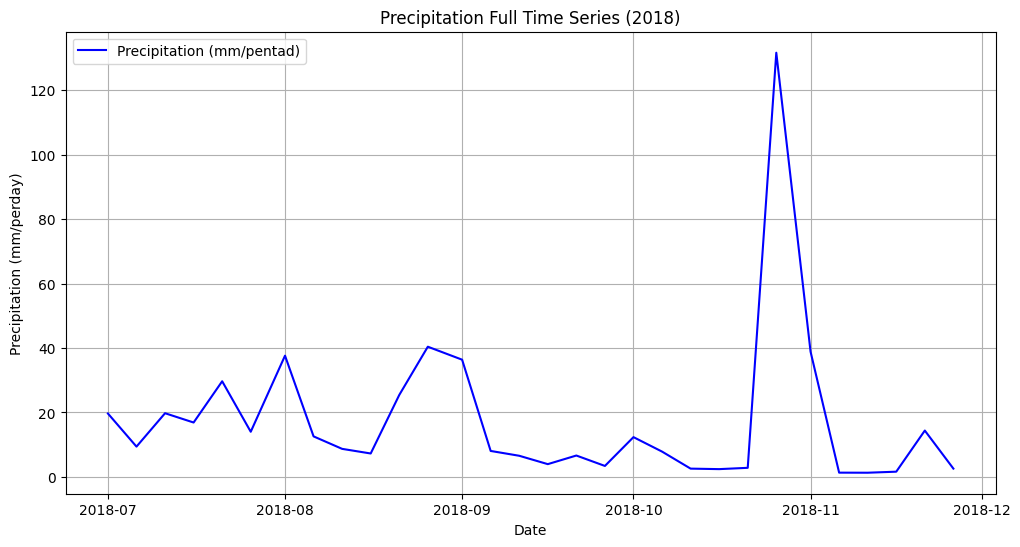

In [10]:
# Load CHIRPS data
chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/PENTAD') \
    .filterBounds(aoi) \
    .filterDate(chirps_start_date, chirps_end_date)  # Use config dates


# Function to add date as a property to each image
def add_date_property(image):
    return image.set('date', image.date().format('YYYY-MM-dd'))

# Map the function to the collection
chirps_with_date = chirps.map(add_date_property)

# Reduce the CHIRPS data to mean precipitation values over the AOI
def extract_precipitation(image):
    mean_precip = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=1000
    ).get('precipitation')  # Key for precipitation in CHIRPS
    return ee.Feature(None, {'date': image.get('date'), 'precipitation': mean_precip})

precipitation_features = chirps_with_date.map(extract_precipitation)

# Convert to list of dictionaries
precipitation_list = precipitation_features.getInfo()['features']

# Extract dates and precipitation into a DataFrame
data = pd.DataFrame([
    {'Date': f['properties']['date'], 'Precipitation': f['properties']['precipitation']}
    for f in precipitation_list
])

# Convert date column to datetime
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values(by='Date')

# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['Precipitation'], color='blue', label='Precipitation (mm/pentad)')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm/perday)')
plt.title('Precipitation Full Time Series (2018)') #change the title accordingly
plt.legend()
plt.grid(True)
plt.show()



In [11]:
import plotly.express as px

fig = px.line(data, x='Date', y='Precipitation', title='Precipitation Time Series (2018)', #change the year accordingly
              labels={'Precipitation': 'Precipitation (mm/perday)', 'Date': 'Date'})
fig.show()


# Define Parameters

In [12]:
# Mention dates for which event you want to do analysis
before_start = before_event_start # 20 days before the event
before_end = before_event_end # 1 day before the event
after_start = after_event_start # 1 day after the event
after_end = after_event_end  # 10 days after the event
polarization = "VH" #or 'VH' --> VH mostly is the prefered polarization for flood mapping. However, it always depends on your study area, you can select 'VV' as well.
pass_direction = "ASCENDING" #ASCENDING' or 'DESCENDING' when images are being compared use only one pass direction. Consider changing this parameter, if your image collection is empty. In some areas more Ascending images exist than than descending or the other way around.
difference_threshold = 1.25 #threshodl to be applied on the difference image (after flood- before flood). It has been chosen by trial and error. In case your
      #flood extent result shows many false-positive or negative signals,consider changing it!

# Sentinel-2 Processing

In [13]:
# Load Sentinel-2 dataset ID from config.ini
s2_collection = config['INPUT']['s2_collection']

# Define Sentinel-2 functions
def mask_clouds(image):
    qa = image.select('QA60')  # Sentinel-2 QA60 band for clouds
    cloud_mask = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
    return image.updateMask(cloud_mask)

def calculate_ndwi(image):
    ndwi = image.normalizedDifference(['B3', 'B8']).rename('NDWI')
    return ndwi.updateMask(ndwi).clip(aoi)

# Load Sentinel-2 collection and apply cloud masking
sentinel2 = (
    ee.ImageCollection("COPERNICUS/S2_SR")
    .filterBounds(aoi)
    .filterDate(before_start, after_end)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))  # Increased threshold from 20 to 50
    .map(mask_clouds)  # Apply cloud and shadow masking
)
#%%%%%%%%%%%%%%%%%%%%%%%%%## Added RGB Sentinel-2 Images ###%%%%%%%%%%%%%%%
# ✅ Ensure Sentinel-2 RGB Visualization is Defined
s2_before_rgb = ee.ImageCollection("COPERNICUS/S2") \
    .filterBounds(aoi) \
    .filterDate(before_start, before_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .median() \
    .clip(aoi)

s2_after_rgb = ee.ImageCollection("COPERNICUS/S2") \
    .filterBounds(aoi) \
    .filterDate(after_start, after_end) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .median() \
    .clip(aoi)
#%%%%%%%%%%%%%%%%%%%%%%%%%##RGB Sentinel-2###%%%%%%%%%%%%%%%
# Calculate NDWI for before and after periods
s2_before_collection = sentinel2.filterDate(before_start, before_end).map(calculate_ndwi)
s2_after_collection = sentinel2.filterDate(after_start, after_end).map(calculate_ndwi)

# Check if both collections have valid data
if s2_before_collection.size().getInfo() > 0 and s2_after_collection.size().getInfo() > 0:
    s2_before = s2_before_collection.median()
    s2_after = s2_after_collection.median()

    # Calculate flood extent based on NDWI difference
    S2_Flood = s2_after.subtract(s2_before).gt(0.1).rename('Flood')

    # Mask permanent water bodies
    permanent_water = ee.Image('JRC/GSW1_0/GlobalSurfaceWater').select('seasonality').gte(10)
    S2_Flood = S2_Flood.where(permanent_water, 0).updateMask(permanent_water.Not())

    print("Sentinel-2 Flood Layer Processed ✅")
else:
    print("No valid Sentinel-2 data available for the specified periods.")


/usr/local/lib/python3.11/dist-packages/ee/deprecation.py:207: DeprecationWarning:



Attention required for COPERNICUS/S2_SR! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR


/usr/local/lib/python3.11/dist-packages/ee/deprecation.py:207: DeprecationWarning:



Attention required for COPERNICUS/S2! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2




Sentinel-2 Flood Layer Processed ✅


/usr/local/lib/python3.11/dist-packages/ee/deprecation.py:207: DeprecationWarning:



Attention required for JRC/GSW1_0/GlobalSurfaceWater! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/JRC_GSW1_0_GlobalSurfaceWater




# ✅ Debug: Count Non-Zero Pixels in the S2 Flood Mask
print("S2 Flood Mask Non-Zero Pixels:", S2_Flood.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=aoi,
    scale=10,  # Resolution in meters (adjust if needed)
    maxPixels=1e9,  # Increase pixel limit
    bestEffort=True  # Let GEE adjust pixel count
).getInfo())

 - This code is if you want to count total flood pixels detected, but it needs sometime more execution time, and GEE has some limitations.

## Sentinel-2 Layers Visulization

In [36]:
import geemap
# Initialize a geemap Map object centered on the AOI
Map_S2 = geemap.Map(center=[45.95, 11.02], zoom=8)  # Adjust center to your AOI

# Check if both collections have valid data and visualize
if s2_before_collection.size().getInfo() > 0 and s2_after_collection.size().getInfo() > 0:
    # Add NDWI layers for before and after flood
    Map_S2.addLayer(s2_before, {'min': -0.2, 'max': 0.5, 'palette': ['white', 'blue']}, 'S2 - Before Flood (NDWI)', shown=False)
    Map_S2.addLayer(s2_after, {'min': -0.2, 'max': 0.5, 'palette': ['white', 'blue']}, 'S2 - After Flood (NDWI)', shown=False)

    # Add flood extent layer
    Map_S2.addLayer(S2_Flood, {'palette': 'red'}, 'S2_Flood Extent', shown=False)

    # Add AOI for reference
    Map_S2.addLayer(aoi, {}, 'AOI', shown=False)
else:
    print("No valid Sentinel-2 data available for visualization.")

# Display the map
Map_S2.addLayerControl()  # Add layer controls
Map_S2

Map(center=[45.95, 11.02], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGU…

# Sentinel-1 Processing

In [28]:
# Load dataset IDs from the config.ini file
s1_collection = config['INPUT']['s1_collection']

# Load Sentinel-1 collection
collection = ee.ImageCollection('COPERNICUS/S1_GRD') \
    .filter(ee.Filter.eq('instrumentMode', 'IW')) \
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', polarization)) \
    .filter(ee.Filter.eq('orbitProperties_pass', pass_direction)) \
    .filter(ee.Filter.eq('resolution_meters', 10)) \
    .filterBounds(aoi) \
    .select(polarization)

before_collection = collection.filterDate(before_start, before_end)
after_collection = collection.filterDate(after_start, after_end)

# Create mosaics and apply focal mean (smoothing)
before = before_collection.mosaic().clip(aoi).focal_mean(50, 'circle', 'meters')
after = after_collection.mosaic().clip(aoi).focal_mean(50, 'circle', 'meters')
# Step 1: Calculate Flood Mask
difference = after.divide(before)
flood_mask = difference.gt(difference_threshold)

# Step 2: Refine Flood Mask Using Water Mask
swater = ee.Image('JRC/GSW1_0/GlobalSurfaceWater').select('seasonality')
swater_mask = swater.gte(10)  # Areas with water > 10 months/year
swater_buffered = swater_mask.focal_max(100, 'square', 'meters')  # Expand mask to cover lake edges (post-processing with lakes threshold)

# Apply water mask correction properly
S1_Flood = flood_mask.updateMask(swater_buffered.Not())  # Removes flood pixels in water


# Add flooded areas to map
print("Sentinel-1 Flood Layer calculated.")


Sentinel-1 Flood Layer calculated.


# ✅ Debug: Check non-zero pixels in the final cleaned flood mask
print("S1 Flood Mask Non-Zero Pixels:", S1_Final.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=aoi,
    scale=10,  # Resolution in meters (adjust if needed)
    maxPixels=1e9,  # Increase pixel limit
    bestEffort=True  # Let GEE adjust pixel count
).getInfo())
 - This code is if you want to count total flood pixels detected, but it needs sometime more execution time, and GEE has some limitations.

## Sentinel-1 Layers Visulization

In [34]:

# Create a map and add Sentinel-1 layers
Map_S1 = geemap.Map(center=[46.0, 11.0], zoom=8)  # Adjust center and zoom level as needed

# Add before and after flood Sentinel-1 layers
Map_S1.addLayer(before, {'min': -25, 'max': 0}, 'S1 - Before Flood', shown=False)
Map_S1.addLayer(after, {'min': -25, 'max': 0}, 'S1 - After Flood', shown=False)

# Add Sentinel-1 flood extent layer
Map_S1.addLayer(S1_Flood, {'palette': 'blue'}, 'S1 - Flood Extent', shown=False)

# Add AOI
Map_S1.addLayer(aoi, {}, 'AOI', shown=False)

# Display the map
Map_S1.addLayerControl()  # Add layer control to toggle layers on/off
Map_S1


Map(center=[46.0, 11.0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(…

In [30]:
# ✅ Compute Flooded Areas (Hectares & Square Kilometers)
def compute_area(image, label):
    band_name = image.bandNames().get(0)  # Get the first band dynamically
    pixel_area = image.multiply(ee.Image.pixelArea())  # Multiply by pixel area
    stats = pixel_area.reduceRegion(**{
        'reducer': ee.Reducer.sum(),
        'geometry': aoi,
        'scale': 30,
        'maxPixels': 1e10
    })

    # Get the area value and convert to hectares
    area_ha = stats.getNumber(band_name).divide(10000).getInfo()
    area_sqkm = round(area_ha / 100, 4) if area_ha else "No Data"  # Convert ha to sq km

    return label, round(area_ha, 2) if area_ha else "No Data", area_sqkm

# ✅ Compute Individual Statistics
s1_flood_area = compute_area(S1_Flood, "Sentinel-1 Flooded Area")
s2_flood_area = compute_area(S2_Flood, "Sentinel-2 Flooded Area")

# ✅ Compute Total Flooded Area (Sum of S1 & S2)
if isinstance(s1_flood_area[1], (int, float)) and isinstance(s2_flood_area[1], (int, float)):
    total_flood_area_ha = round(s1_flood_area[1] + s2_flood_area[1], 2)
    total_flood_area_sqkm = round(total_flood_area_ha / 100, 4)
else:
    total_flood_area_ha, total_flood_area_sqkm = "No Data", "No Data"

# ✅ Print Results
print(f"{s1_flood_area[0]}: {s1_flood_area[1]} ha ({s1_flood_area[2]} sq km)")
print(f"{s2_flood_area[0]}: {s2_flood_area[1]} ha ({s2_flood_area[2]} sq km)")
print(f"Total Flooded Area: {total_flood_area_ha} ha ({total_flood_area_sqkm} sq km)")

Sentinel-1 Flooded Area: 34.91 ha (0.3491 sq km)
Sentinel-2 Flooded Area: 88.19 ha (0.8819 sq km)
Total Flooded Area: 123.1 ha (1.231 sq km)


#Fina Viulization (demo)

In [31]:
import geemap
from ipyleaflet import WidgetControl
import ipywidgets as widgets

# ✅ Merge Sentinel-1 & Sentinel-2 Flood Detections (Union)
S1_Vis = S1_Flood.visualize(**{'bands': ['VH'], 'palette': ['blue']})  # S1 in Blue
S2_Vis = S2_Flood.visualize(**{'bands': ['Flood'], 'palette': ['blue']})  # S2 in Blue

# ✅ Blend both for final merged visualization
Merged_Flood = ee.ImageCollection([S1_Vis, S2_Vis]).mosaic()

# ✅ Visualization Setup
Map_Flood = geemap.Map(center=[46.0, 11.0], zoom=8)

# ✅ Add Sentinel-1 before and after layers (initially turned off)
Map_Flood.addLayer(before, {'min': -25, 'max': 0}, 'S1 - Before Flood', shown=False)
Map_Flood.addLayer(after, {'min': -25, 'max': 0}, 'S1 - After Flood', shown=False)

# ✅ Add Sentinel-2 RGB Layers (initially turned off)
Map_Flood.addLayer(s2_before_rgb, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000},
                   'S2 - Before Flood (RGB)', shown=False)
Map_Flood.addLayer(s2_after_rgb, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000},
                   'S2 - After Flood (RGB)', shown=False)

# ✅ Add Merged Flood Layer (initially turned off)
Map_Flood.addLayer(Merged_Flood, {}, 'Flood Extent (S1 + S2)', shown=False)

# ✅ Add AOI Boundary (initially turned off)
Map_Flood.addLayer(aoi, {}, 'AOI', shown=False)

# ✅ Create Custom Legend Using ipywidgets (Blue for Flood Extent)
legend_html = widgets.HTML(
    value=f"""
    <div style="background-color: white; padding: 10px; border: 2px solid black;">
        <h4>Legend</h4>
        <div style="display: flex; align-items: center;">
            <div style="width: 15px; height: 15px; background-color: blue; margin-right: 5px;"></div>Flood Extent
        </div>
        <div style="margin-top: 10px;"><strong>Total Inundated Area:</strong> {total_flood_area_sqkm} sq km</div>
    </div>
    """
)

# ✅ Add Legend to Map
legend_control = WidgetControl(widget=legend_html, position="bottomright")
Map_Flood.add_control(legend_control)

# ✅ Display the map with interactive controls
Map_Flood.addLayerControl()
Map_Flood




Map(center=[46.0, 11.0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(…

# NDWI Histogram

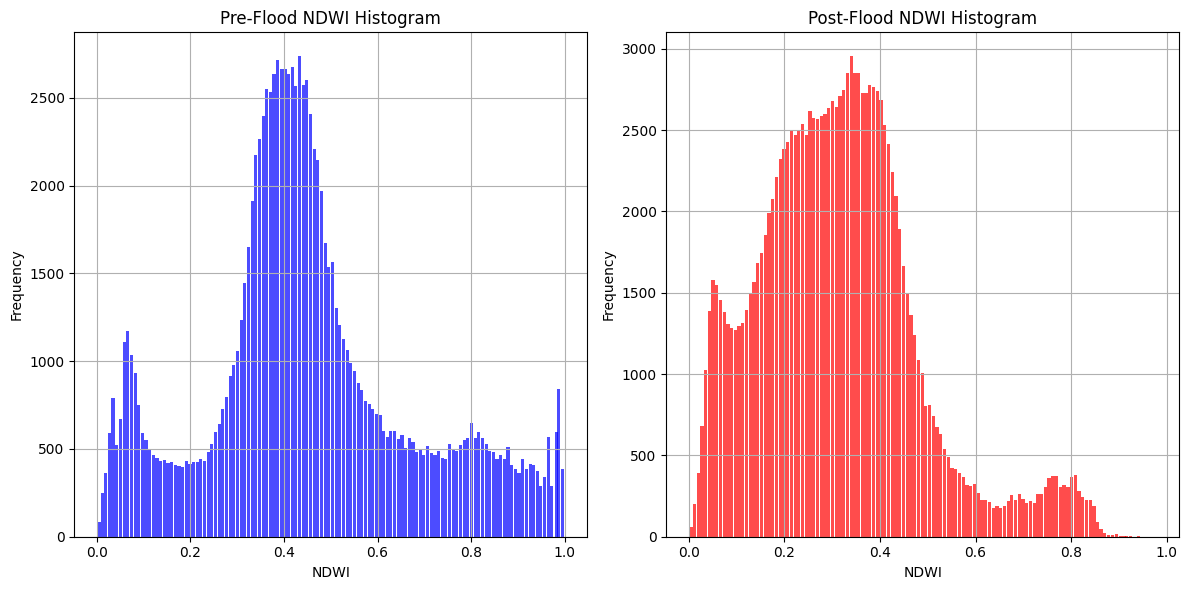

In [32]:
# Assuming 's2_before' and 's2_after' are your NDWI images from the previous provided code snippet.
# Define your AOI and other necessary parameters if not already defined.

# Function to fetch histogram data from an image
def get_histogram(image, region, scale=30, max_pixels=1e8, buckets=100):
    """Fetch histogram data for NDWI from a given image."""
    ndwi_histogram = image.select('NDWI').reduceRegion(
        reducer=ee.Reducer.histogram(buckets),
        geometry=region,
        scale=scale,
        maxPixels=max_pixels
    ).get('NDWI')
    return ee.Dictionary(ndwi_histogram).getInfo()

# Calculate histograms
hist_before = get_histogram(s2_before, aoi)
hist_after = get_histogram(s2_after, aoi)

# Function to plot histogram
def plot_histogram(data, title='Histogram', color='blue'):
    """Plot histogram from the Earth Engine histogram data."""
    bucket_limits = data['bucketMeans']
    counts = data['histogram']
    width = bucket_limits[1] - bucket_limits[0]
    plt.bar(bucket_limits, counts, width=width, color=color, alpha=0.7)
    plt.title(title)
    plt.xlabel('NDWI')
    plt.ylabel('Frequency')
    plt.grid(True)

# Plotting
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plot_histogram(hist_before, 'Pre-Flood NDWI Histogram', 'blue')
plt.subplot(1, 2, 2)
plot_histogram(hist_after, 'Post-Flood NDWI Histogram', 'red')
plt.tight_layout()
plt.show()



#Export Layers in Raster and Vector

In [33]:
# Read the Google Drive folder from the config file
google_drive_folder = config['OUTPUT']['google_drive_folder']

# ✅ Export Sentinel-2 Flood Raster
task_s2_raster = ee.batch.Export.image.toDrive(
    image=S2_Flood,  # ✅ Using the correct Sentinel-2 Flood Layer
    description='Sentinel-2_Flood_Raster',
    fileNamePrefix='Sentinel2_Flood',
    folder=google_drive_folder,  # Fetch from config file
    region=aoi,
    scale=10,
    maxPixels=1e10
)
task_s2_raster.start()

# Convert Sentinel-2 flood raster to vectors
s2_flood_vec = S2_Flood.reduceToVectors(
    scale=10,
    geometryType='polygon',
    geometry=aoi,
    eightConnected=False,
    bestEffort=True
)

# ✅ Export Sentinel-2 Flood Vector
task_s2_vector = ee.batch.Export.table.toDrive(
    collection=s2_flood_vec,
    description='Sentinel-2_Flood_Vector',
    fileFormat='SHP',
    folder=google_drive_folder  # Fetch from config file
)
task_s2_vector.start()

# ✅ Export Sentinel-1 Flood Raster (CLEANED)
task_s1_raster = ee.batch.Export.image.toDrive(
    image=S1_Flood,  # ✅ Using the CLEANED Sentinel-1 Flood Layer
    description='Sentinel-1_Flood_Raster',
    fileNamePrefix='Sentinel1_Flood_Cleaned',
    folder=google_drive_folder,  # Fetch from config file
    region=aoi,
    scale=10,
    maxPixels=1e10
)
task_s1_raster.start()

# Convert Sentinel-1 cleaned flood raster to vectors
s1_flood_vec = S1_Flood.reduceToVectors(
    scale=10,
    geometryType='polygon',
    geometry=aoi,
    eightConnected=False,
    bestEffort=True
)

# ✅ Export Sentinel-1 Cleaned Flood Vector
task_s1_vector = ee.batch.Export.table.toDrive(
    collection=s1_flood_vec,
    description='Sentinel-1_Flood_Vector_Cleaned',
    fileFormat='SHP',
    folder=google_drive_folder  # Fetch from config file
)
task_s1_vector.start()

print("Export tasks started.")


Export tasks started.


#Post-Processing
This version of the code provides an initial estimation of flood detection but requires further post-processing steps to enhance accuracy. These include refining the thresholds, integrating auxiliary datasets, and improving water body masking, which are currently underway.